In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_applications = pd.read_csv("./data-cleaned/applications.csv")
df_categories = pd.read_csv("./data-cleaned/categories_clean.csv")
df_developers = pd.read_csv("./data/developers.csv")
df_genres = pd.read_csv("./data-cleaned/genres_clean.csv")
df_platforms = pd.read_csv("./data/platforms.csv")
df_publishers = pd.read_csv("./data/publishers.csv")
df_reviews = pd.read_csv("./data/reviews.csv")
df_application_categories = pd.read_csv("./data/application_categories.csv")
df_application_developers = pd.read_csv("./data/application_developers.csv")
df_application_genres = pd.read_csv("./data/application_genres.csv")
df_application_platforms = pd.read_csv("./data/application_platforms.csv")
df_application_publishers = pd.read_csv("./data/application_publishers.csv")

### Mi pregunta y su tipo:

¿Se puede predecir el precio de un juego a partir de sus características como géneros, número de logros, plataformas e idiomas soportados?

Tipo: Regresión supervisada. Target: price_usd. 🎯

## Celda 1 — EDA del target (precio)

ANTES de filtrar:
Juegos: 137,252
Max: $891000.00

DESPUÉS de filtrar (precio <= $60):
Juegos: 135,866
count    135866.000000
mean          8.136742
std           8.695851
min           0.440000
25%           2.790000
50%           4.990000
75%           9.990000
max          60.000000
Name: price_usd, dtype: float64


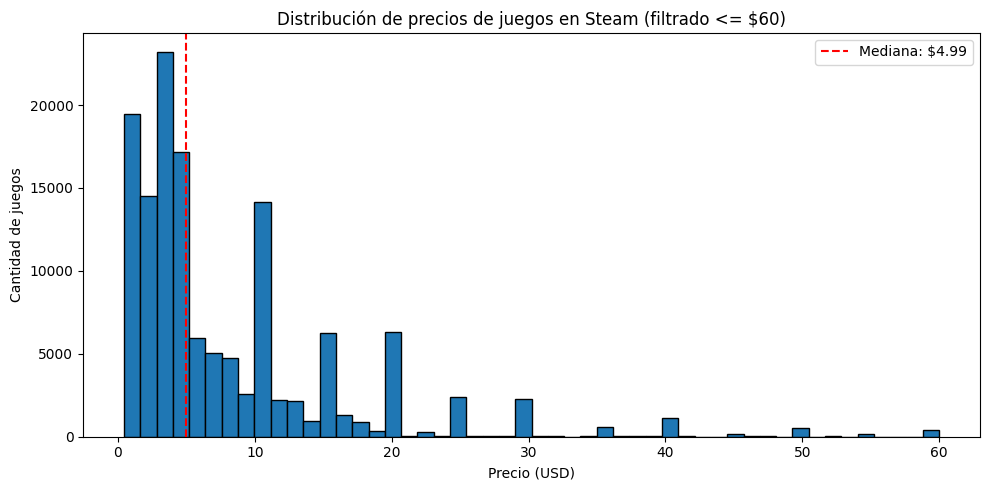

In [3]:
# === EDA: Distribución del precio (filtrando outliers) ===
pagados = df_applications[
    (df_applications['is_free'] == False) & 
    (df_applications['mat_final_price'] > 0)
].copy()

pagados['price_usd'] = pagados['mat_final_price'] / 100

print("ANTES de filtrar:")
print(f"Juegos: {len(pagados):,}")
print(f"Max: ${pagados['price_usd'].max():.2f}")

# Filtrar: quedarse con precios <= $60 (precio AAA estándar)
pagados = pagados[pagados['price_usd'] <= 60].copy()

print(f"\nDESPUÉS de filtrar (precio <= $60):")
print(f"Juegos: {len(pagados):,}")
print(pagados['price_usd'].describe())

# Histograma limpio
plt.figure(figsize=(10, 5))
plt.hist(pagados['price_usd'], bins=50, edgecolor='black')
plt.xlabel('Precio (USD)')
plt.ylabel('Cantidad de juegos')
plt.title('Distribución de precios de juegos en Steam (filtrado <= $60)')
plt.axvline(pagados['price_usd'].median(), color='red', linestyle='--', 
            label=f"Mediana: ${pagados['price_usd'].median():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

El 75% de los juegos pagados en Steam cuesta $9.99 o menos, con una mediana de $4.99. La distribución presenta picos en precios psicológicos estándar ($0.99, $4.99, $9.99, $14.99, $19.99), sugiriendo que los desarrolladores no fijan precios libremente sino que siguen convenciones del mercado. Esta concentración en valores bajos representa un desafío para los modelos de regresión.


## Celda 2 — Precio por género

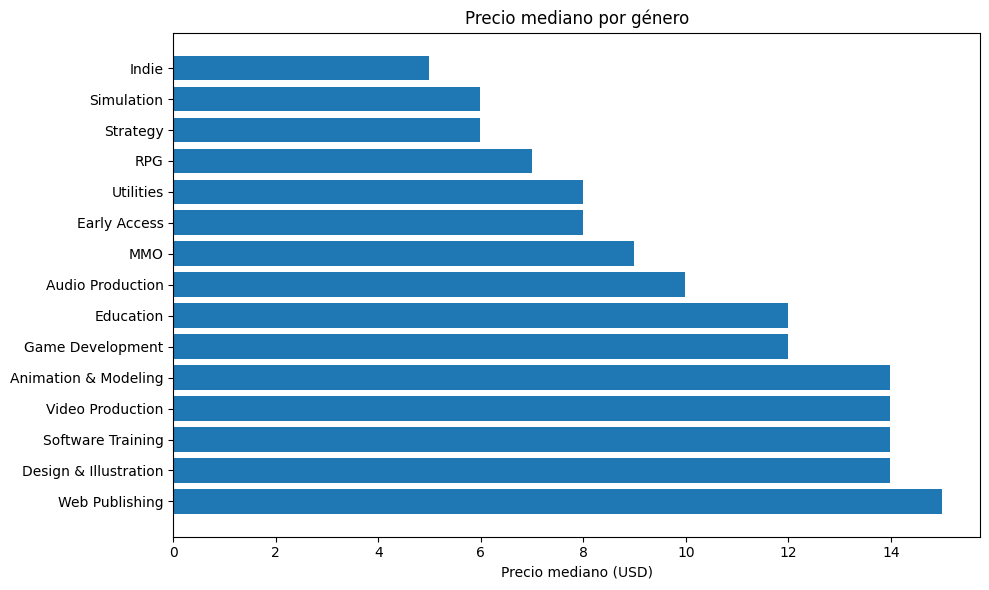

In [4]:
# === ¿Influye el género en el precio? ===
app_gen = df_application_genres.merge(df_genres, left_on='genre_id', right_on='id')
app_gen = app_gen.rename(columns={'name': 'genre_name'})

pagados_gen = pagados.merge(app_gen[['appid', 'genre_name']], on='appid')

top_generos = pagados_gen.groupby('genre_name')['price_usd'].agg(['mean', 'median', 'count'])
top_generos = top_generos[top_generos['count'] > 100].sort_values('median', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_generos.index, top_generos['median'])
plt.xlabel('Precio mediano (USD)')
plt.title('Precio mediano por género')
plt.tight_layout()
plt.show()

El género influye claramente en el precio. Los juegos Indie son los más baratos (mediana $4.99), mientras que las aplicaciones de software creativo (Web Publishing, Design & Illustration, Video Production, Animation & Modeling) son las más caras, superando los $14 USD. Esto tiene sentido porque esos "géneros" no son realmente juegos sino herramientas profesionales vendidas en Steam. Entre los juegos propiamente tales, los RPG y MMO son los más caros (~$7-9), probablemente por su mayor complejidad y contenido, mientras que los Indie y Simulation se posicionan como las opciones más accesibles. Esto confirma que el género será una feature relevante para predecir precio en el modelo de regresión.


## Celda 3 — Construir features

In [5]:
# === Construcción de features para el modelo ===
import re

# Contar géneros por juego
n_genres = df_application_genres.groupby('appid').size().rename('n_genres')

# Contar plataformas por juego
n_platforms = df_application_platforms.groupby('appid').size().rename('n_platforms')

# Contar idiomas soportados
def count_langs(x):
    if pd.isna(x): return 0
    clean = re.sub(r'<[^>]+>', '', str(x))
    clean = re.sub(r'\*', '', clean)
    return len([l for l in clean.split(',') if l.strip()])

pagados['n_languages'] = pagados['supported_languages'].apply(count_langs)

# Parsear año
pagados['release_date'] = pd.to_datetime(pagados['release_date'], errors='coerce')
pagados['release_year'] = pagados['release_date'].dt.year

# Merge de features
pagados = pagados.merge(n_genres, on='appid', how='left')
pagados = pagados.merge(n_platforms, on='appid', how='left')

# Seleccionar features y target
features = ['mat_achievement_count', 'n_genres', 'n_platforms', 
            'n_languages', 'release_year']
target = 'price_usd'

# Eliminar nulos
modelo_df = pagados[features + [target]].dropna()
print(f"Filas para modelar: {len(modelo_df):,}")
print(modelo_df.describe())

Filas para modelar: 51,903
       mat_achievement_count      n_genres   n_platforms   n_languages  \
count           51903.000000  51903.000000  51903.000000  51903.000000   
mean               36.438530      2.811745      1.421170      6.928713   
std               211.857108      1.241545      0.721353     15.278029   
min                 0.000000      1.000000      1.000000      0.000000   
25%                10.000000      2.000000      1.000000      1.000000   
50%                18.000000      3.000000      1.000000      2.000000   
75%                32.000000      3.000000      2.000000      8.000000   
max              9821.000000     10.000000      3.000000    103.000000   

       release_year     price_usd  
count  51903.000000  51903.000000  
mean    2021.110244      8.559557  
std        3.232805      8.565269  
min     2004.000000      0.490000  
25%     2019.000000      2.990000  
50%     2022.000000      5.000000  
75%     2024.000000     10.390000  
max     2025.00000

## Celda 4 — Train / Test split

In [6]:
# === Separación en conjuntos de entrenamiento y prueba ===
from sklearn.model_selection import train_test_split

X = modelo_df[features]
y = modelo_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (36332, 5)
y_train: (36332,)
X_test:  (15571, 5)
y_test:  (15571,)


## Celda 5 — Modelo 1: Regresión Lineal (features originales)

In [7]:
# === Sección 1: Regresión Lineal Simple ===
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

# Coeficientes del modelo
print("Intercepto:", round(modelo_lr.intercept_, 4))
coefs = pd.DataFrame({
    'Feature': features,
    'Coeficiente': modelo_lr.coef_
})
print(coefs)

Intercepto: -60.3283
                 Feature  Coeficiente
0  mat_achievement_count     0.000229
1               n_genres    -0.259078
2            n_platforms     0.012867
3            n_languages    -0.021837
4           release_year     0.034514


Interpretación de cada coeficiente:
* release_year = 0.035: por cada año más reciente, el precio sube $0.035 USD. Es decir, un juego de 2025 se predice ~$0.70 más caro que uno de 2005. Efecto muy pequeño.

* n_genres = -0.259: cada género adicional reduce el precio en $0.26. Esto podría indicar que juegos con muchos tags tienden a ser indies baratos.

* mat_achievement_count = 0.000229: efecto casi nulo. Un juego con 1.000 logros solo subiría ~$0.23.

* n_languages = -0.022: más idiomas reduce ligeramente el precio (contraproducente, pero el efecto es mínimo).\

* n_platforms = 0.013: prácticamente cero impacto.

Problema: El intercepto es -60.33 y los coeficientes son diminutos. El modelo está diciendo "no puedo explicar el precio con estas variables" — casi todas las predicciones caen cerca de la media (~$8).

## Celda 6 — Tabla de residuos (⭐ NUEVO del Lab 5)

In [8]:
# === Tabla de residuos: primeros 10 valores ===
residuos = y_test.values[:10] - y_pred_lr[:10]

df_residuos = pd.DataFrame({
    'y_real': y_test.values[:10],
    'y_prediccion': np.round(y_pred_lr[:10], 2),
    'residuo': np.round(residuos, 2)
})
print(df_residuos)

   y_real  y_prediccion  residuo
0    7.99          7.85     0.14
1    4.99          8.88    -3.89
2   38.00          7.38    30.62
3    0.99          9.10    -8.11
4    9.99          8.17     1.82
5    2.49          8.33    -5.84
6    1.99          8.00    -6.01
7   12.99          8.24     4.75
8    6.99          8.47    -1.48
9    2.99          8.55    -5.56


Los residuos confirman un problema grave: casi todas las predicciones rondan $7-9 USD (la media del dataset), sin importar el precio real. Cuando el juego cuesta $38, el modelo predice $7.38; cuando cuesta $0.99, predice $9.10. El modelo prácticamente aprendió a predecir la media y nada más. Esto es consistente con un R² cercano a 0.

**Análisis de residuos:**
- Los residuos representan la diferencia entre el valor real y la predicción (y_real - y_pred).
- Si el residuo es **positivo**, el modelo subestimó el precio (predijo menos de lo real).
- Si el residuo es **negativo**, el modelo sobreestimó el precio (predijo más de lo real).
- Son útiles porque nos permiten evaluar qué tan bien se ajusta el modelo y detectar patrones 
  de error sistemáticos.

## Celda 7 — Modelo 2: Regresión Lineal con PolynomialFeatures (⭐ NUEVO del Lab 5)

In [9]:
# === Sección 2: Mejorar el modelo con transformación polinomial ===
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print("Features originales:", X_train.shape[1])
print("Features polinomiales:", X_train_poly.shape[1])
print("Nombres:", poly.get_feature_names_out())

# Entrenar regresión lineal con features polinomiales
modelo_lr_poly = LinearRegression()
modelo_lr_poly.fit(X_train_poly, y_train)
y_pred_lr_poly = modelo_lr_poly.predict(X_test_poly)

Features originales: 5
Features polinomiales: 21
Nombres: ['1' 'mat_achievement_count' 'n_genres' 'n_platforms' 'n_languages'
 'release_year' 'mat_achievement_count^2' 'mat_achievement_count n_genres'
 'mat_achievement_count n_platforms' 'mat_achievement_count n_languages'
 'mat_achievement_count release_year' 'n_genres^2' 'n_genres n_platforms'
 'n_genres n_languages' 'n_genres release_year' 'n_platforms^2'
 'n_platforms n_languages' 'n_platforms release_year' 'n_languages^2'
 'n_languages release_year' 'release_year^2']


## Celda 8 — Modelo 3: Random Forest (features originales)

In [10]:
# === Sección 3: Random Forest con features originales ===
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

## Celda 9 — Modelo 4: Random Forest con PolynomialFeatures (⭐ NUEVO del Lab 5)

In [11]:
# === Sección 4: Random Forest con features polinomiales ===
modelo_rf_poly = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_poly.fit(X_train_poly, y_train)
y_pred_rf_poly = modelo_rf_poly.predict(X_test_poly)

## Celda 10 — Tabla comparativa de 4 modelos (⭐ MEJORADO según Lab 5)

In [12]:
# === Sección 5: Comparación de modelos ===
# Predicciones en TRAIN (para detectar overfitting)
y_pred_lr_train = modelo_lr.predict(X_train)
y_pred_lr_poly_train = modelo_lr_poly.predict(poly.transform(X_train))
y_pred_rf_train = modelo_rf.predict(X_train)
y_pred_rf_poly_train = modelo_rf_poly.predict(poly.transform(X_train))

# Función auxiliar (como en el Lab 5)
def calcular_metricas(y_true, y_pred, y_true_train, y_pred_train):
    return {
        "R² train": r2_score(y_true_train, y_pred_train),
        "R² test": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

# Tabla comparativa
resumen = pd.DataFrame({
    "Reg. Lineal (Original)": calcular_metricas(y_test, y_pred_lr, y_train, y_pred_lr_train),
    "Reg. Lineal (Polinomial)": calcular_metricas(y_test, y_pred_lr_poly, y_train, y_pred_lr_poly_train),
    "Random Forest (Original)": calcular_metricas(y_test, y_pred_rf, y_train, y_pred_rf_train),
    "Random Forest (Polinomial)": calcular_metricas(y_test, y_pred_rf_poly, y_train, y_pred_rf_poly_train),
}).T

print(resumen)

                            R² train   R² test      RMSE       MAE
Reg. Lineal (Original)      0.003134  0.002287  8.550186  6.070440
Reg. Lineal (Polinomial)    0.060477  0.053237  8.329010  5.874422
Random Forest (Original)    0.737936  0.088983  8.170262  5.543228
Random Forest (Polinomial)  0.739458  0.105504  8.095841  5.499406


Análisis modelo por modelo:

Regresión Lineal (Original) — R² = 0.002:
Desastroso. Explica el 0.2% de la varianza del precio. No hay relación lineal entre estas features y el precio. R² train ≈ R² test (ambos cercanos a 0), lo que confirma subajuste (underfitting): el modelo es demasiado simple para capturar la relación.

Regresión Lineal (Polinomial) — R² = 0.053:
Mejoró 25x respecto al lineal, pero sigue siendo pésimo (solo 5.3% de varianza explicada). Las interacciones polinomiales ayudan algo pero no suficiente. También presenta subajuste (R² train ≈ R² test, ambos bajos).

Random Forest (Original) — R² train=0.738, R² test=0.089:
Caso clásico de sobreajuste (overfitting). El modelo explica 73.8% de los datos de entrenamiento pero solo 8.9% en datos nuevos. La brecha de 0.65 entre train y test es enorme: el modelo memorizó patrones del training set sin aprender la relación real precio-features.

Random Forest (Polinomial) — R² train=0.739, R² test=0.106:
Mismo problema de overfitting. Agregar features polinomiales mejoró ligeramente el test (0.089 → 0.106) pero la brecha sigue siendo enorme. Es el "menos malo" de los cuatro, pero sigue sin ser útil.

Sobre MAE: Todos los modelos tienen MAE entre $5.50 y $6.07 USD. Considerando que la mediana del precio es $5.00, un error promedio de ~$5.50 significa que el modelo se equivoca tanto como el precio mismo — no tiene valor predictivo real.

**Análisis de la tabla:**
- Si R² train >> R² test → el modelo tiene **sobreajuste (overfitting)**: memorizó los datos 
  de entrenamiento pero no generaliza.
- Si R² train ≈ R² test y ambos son bajos → el modelo tiene **subajuste (underfitting)**: 
  no captura la complejidad del problema.
- El mejor modelo es el que tiene **R² test más alto** con una diferencia razonable respecto 
  a R² train.

## Celda 11 — Curva de overfitting con DecisionTree (⭐ NUEVO del Lab 5)

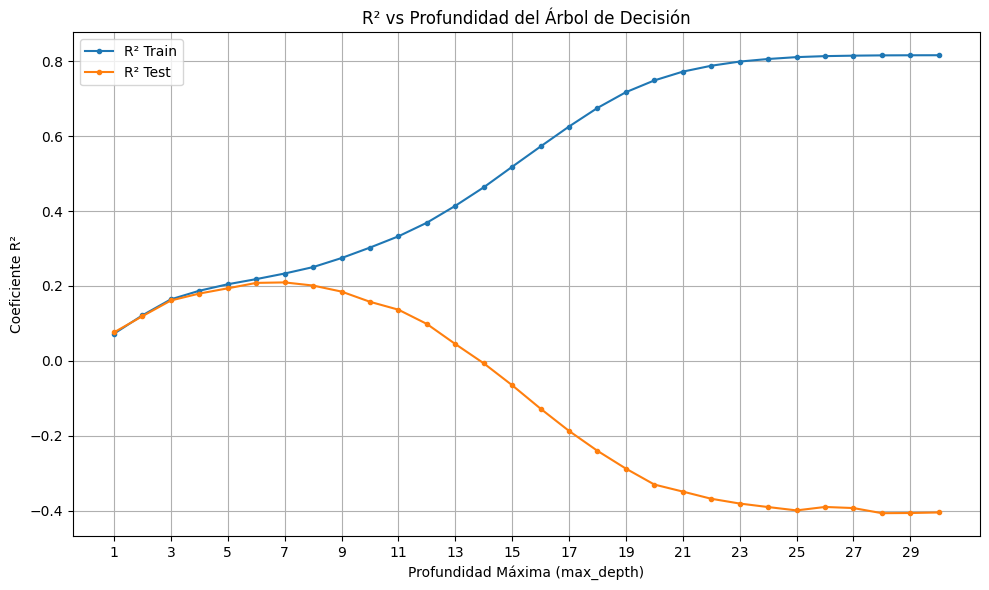

In [13]:
# === Sección 6: Visualizar overfitting con DecisionTreeRegressor ===
from sklearn.tree import DecisionTreeRegressor

res = []
for md in range(1, 31):
    tree = DecisionTreeRegressor(max_depth=md, random_state=42)
    tree.fit(X_train, y_train)
    
    r2_train = tree.score(X_train, y_train)
    r2_test = tree.score(X_test, y_test)
    
    res.append({'profundidad': md, 'r2_train': r2_train, 'r2_test': r2_test})

df_depth = pd.DataFrame(res)

plt.figure(figsize=(10, 6))
plt.plot(df_depth['profundidad'], df_depth['r2_train'], label='R² Train', marker='o', markersize=3)
plt.plot(df_depth['profundidad'], df_depth['r2_test'], label='R² Test', marker='o', markersize=3)
plt.title('R² vs Profundidad del Árbol de Decisión')
plt.xlabel('Profundidad Máxima (max_depth)')
plt.ylabel('Coeficiente R²')
plt.xticks(range(1, 31, 2))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

El gráfico muestra el patrón de overfitting más claro posible:

R² Train sube constantemente hasta ~0.82 (el árbol memoriza los datos de entrenamiento).

R² Test alcanza su máximo (~0.20) en profundidad 7-9, y luego colapsa hasta valores negativos (-0.40).

Un R² negativo significa que el modelo predice peor que simplemente adivinar la media. A partir de profundidad ~13, el árbol es tan complejo que sus predicciones son contraproducentes.

Rango óptimo: profundidad 5-9, donde el R² test es máximo (~0.20) y la brecha con train es tolerable. Pero incluso el mejor R² test es solo 0.20.

**Interpretación:**
- A medida que aumenta la profundidad, R² train sube hasta llegar a ~1.0 (memorización perfecta).
- R² test sube hasta cierto punto y luego se estanca o baja: esa es la señal de **overfitting**.
- El rango óptimo de profundidad es donde R² test es máximo y la brecha con R² train es pequeña.

## Celda 12 — Importancia de features (se mantiene)

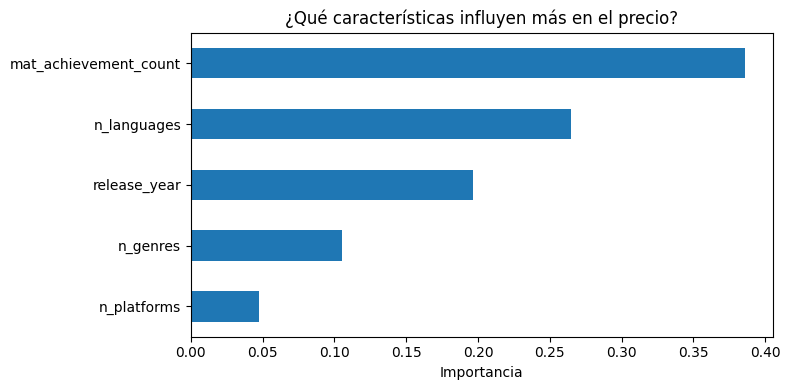

In [15]:
# === ¿Qué features influyen más en el precio? ===
importancia = pd.Series(modelo_rf.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 4))
importancia.plot.barh()
plt.xlabel('Importancia')
plt.title('¿Qué características influyen más en el precio?')
plt.tight_layout()
plt.show()

Interpretación: El número de logros es la feature que más usa el Random Forest para predecir precio (39% de importancia), seguido del número de idiomas (26%) y año de lanzamiento (20%). Tiene sentido: juegos con muchos logros y muchos idiomas suelen ser proyectos más ambiciosos y por ende más caros. n_platforms casi no aporta señal (solo 5%), lo que confirma lo que vimos en la exploración: casi todos los juegos soportan pocas plataformas y la variabilidad es mínima.

## Celda 13 — Predicción vs Realidad (se mantiene)

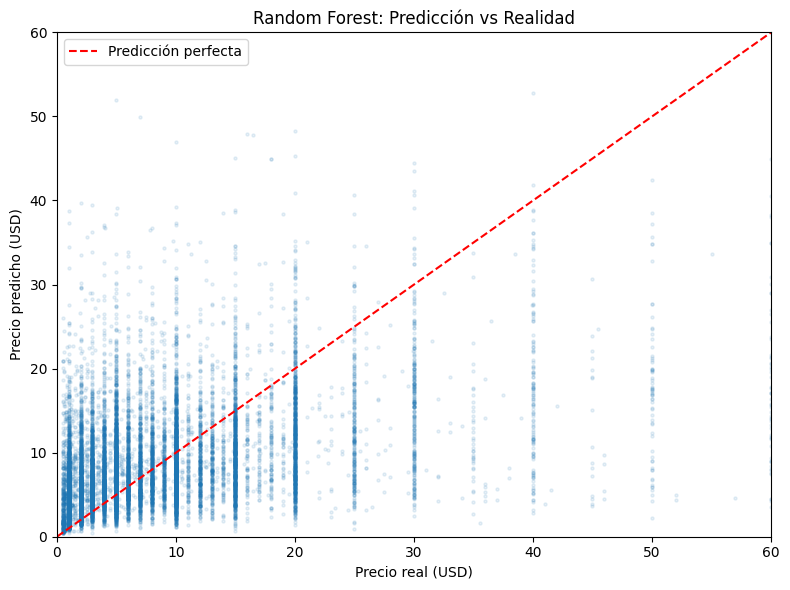

In [16]:
# === Predicción vs Valor Real (mejor modelo) ===
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.1, s=5)
plt.plot([0, 60], [0, 60], color='red', linestyle='--', label='Predicción perfecta')
plt.xlim(0, 60)
plt.ylim(0, 60)
plt.xlabel('Precio real (USD)')
plt.ylabel('Precio predicho (USD)')
plt.title('Random Forest: Predicción vs Realidad')
plt.legend()
plt.tight_layout()
plt.show()

El scatter confirma visualmente lo que dicen los números:

La mayoría de predicciones se concentran entre $0-15, sin importar el precio real. El modelo no puede predecir precios altos.
Las líneas verticales corresponden a los precios psicológicos ($4.99, $9.99, $14.99, $19.99) — muchos juegos comparten esos precios pero el modelo les asigna predicciones distintas.
Los puntos deberían caer sobre la línea roja si la predicción fuera perfecta. En cambio, forman una nube dispersa, especialmente para precios >$20 donde el modelo falla completamente.

### Propuesta Metodológica — ¿Se puede predecir el precio de un juego?

**Preprocesamiento:**
- Se filtraron solo juegos pagados (is_free == False) con precio entre $0.44 y $60 USD, 
  eliminando outliers (precio máximo original: $891.000) y aplicaciones de software 
  no-gaming. El corte de $60 corresponde al precio estándar de un título AAA.
- Se construyeron features numéricas a partir de las tablas relacionales del dataset 
  mediante operaciones de merge y groupby: número de géneros (n_genres), número de 
  plataformas (n_platforms) y número de idiomas soportados (n_languages).
- Se parseó release_date para extraer release_year como variable numérica.
- Se eliminaron filas con valores nulos, obteniendo un pool modelable de 51.903 juegos.

**Features seleccionadas:** mat_achievement_count, n_genres, n_platforms, 
n_languages, release_year.

**Target:** price_usd (variable continua → tarea de regresión supervisada).

**Modelos a comparar (siguiendo la metodología del Lab 5):**
1. Regresión Lineal con features originales (baseline lineal).
2. Regresión Lineal con PolynomialFeatures (degree=2) para capturar interacciones 
   y relaciones cuadráticas entre variables.
3. Random Forest Regressor con features originales (modelo no lineal).
4. Random Forest con PolynomialFeatures.
5. DecisionTreeRegressor variando max_depth de 1 a 30, para visualizar la frontera 
   entre subajuste y sobreajuste.

**Métricas de evaluación:**
- R² (coeficiente de determinación): proporción de la varianza del precio explicada 
  por el modelo. Rango [0,1] donde 1 = predicción perfecta. Valores negativos indican 
  que el modelo predice peor que la media.
- RMSE (Root Mean Squared Error): error promedio en USD, penaliza errores grandes.
- MAE (Mean Absolute Error): error promedio en USD, más interpretable.
- Comparación R² train vs R² test para detectar sobreajuste.

**Justificación:**
- Se comparan modelos lineales vs no lineales porque la distribución del precio es 
  right-skewed con picos en precios psicológicos ($4.99, $9.99, $14.99), sugiriendo 
  relaciones no lineales.
- Se usa PolynomialFeatures siguiendo el Lab 5, donde se demostró que agregar 
  combinaciones polinomiales permite al modelo lineal capturar relaciones no lineales.
- Se incluye la curva de overfitting del DecisionTree para identificar el balance 
  entre complejidad y generalización.

### Resultado Preliminar — ¿Se puede predecir el precio?

**Datos utilizados:** 51.903 juegos pagados, divididos en 36.332 para entrenamiento 
(70%) y 15.571 para prueba (30%).

#### Resultados de los modelos

| Modelo | R² Train | R² Test | RMSE (USD) | MAE (USD) |
|--------|----------|---------|------------|-----------|
| Reg. Lineal (Original) | 0.003 | 0.002 | $8.55 | $6.07 |
| Reg. Lineal (Polinomial) | 0.060 | 0.053 | $8.33 | $5.87 |
| Random Forest (Original) | 0.738 | 0.089 | $8.17 | $5.54 |
| Random Forest (Polinomial) | 0.739 | 0.106 | $8.10 | $5.50 |

#### Análisis

La Regresión Lineal con features originales obtuvo un R² de 0.002, lo que 
significa que el modelo explica apenas el 0.2% de la variabilidad del precio. 
Los coeficientes obtenidos son diminutos y las predicciones convergen a la media 
del precio (~$8.56 USD), confirmando un caso severo de **subajuste**: no existe 
una relación lineal significativa entre las 5 features seleccionadas y el precio.

La transformación con PolynomialFeatures (de 5 a 21 features) mejoró el R² a 
0.053, lo que sugiere que existen interacciones entre variables (por ejemplo, 
mat_achievement_count × n_languages) que capturan algo de señal adicional, 
pero insuficiente.

El Random Forest logró un R² de entrenamiento de 0.738 pero solo 0.089 en 
test, una caída del 88%. Este es un caso clásico de **sobreajuste**: el modelo 
memorizó los patrones del conjunto de entrenamiento pero no generalizó. Esto se 
confirma con la curva de overfitting del DecisionTree, donde el R² test alcanza 
un máximo de ~0.20 en profundidad 7-9 y luego colapsa hasta valores negativos 
(-0.40), indicando que el modelo predice peor que simplemente usar la media.

El análisis de importancia de features reveló que mat_achievement_count (39%) y 
n_languages (26%) son las variables más influyentes, seguidas por release_year 
(20%), n_genres (10%) y n_platforms (5%). Esto tiene sentido: juegos con más 
logros e idiomas tienden a ser proyectos más ambiciosos y costosos.

El gráfico de predicción vs realidad confirma visualmente que ningún modelo 
logra predecir precios altos (>$20 USD), concentrando casi todas las 
predicciones en el rango $0-15.

#### Conclusión del experimento preliminar

**Con las features actuales, no es posible predecir el precio de un juego de 
manera confiable.** El mejor modelo (Random Forest Polinomial, R² test = 0.106) 
apenas explica el 10.6% de la varianza del precio, con un error promedio de 
$5.50 USD — prácticamente igual al precio mediano del dataset ($5.00). Esto 
indica que el precio de un videojuego depende fuertemente de factores que NO 
están en nuestras features actuales (reputación del estudio, marketing, IP 
reconocida, calidad percibida, demanda del mercado).

Este resultado es valioso porque demuestra que el precio no es una variable 
que se pueda derivar trivialmente de las características técnicas del juego, 
sino que depende de decisiones estratégicas del desarrollador y condiciones 
de mercado.

#### Mejoras propuestas para el Hito 2

1. **Agregar géneros como variables one-hot** (en vez de solo contar n_genres), 
   ya que vimos que RPGs cuestan más que Indie.
2. **Incorporar información del developer/publisher** — estudios reconocidos 
   probablemente fijan precios más altos.
3. **Transformar el target con log(price)** para manejar la distribución 
   right-skewed.
4. **Incluir recommendations_total** como feature (éxito → precio más alto).
5. **Probar regularización con Ridge/Lasso** para controlar overfitting.
6. **Usar datos de reviews** (promedio de votos positivos, playtime promedio) 
   como features adicionales.